# 02 — Feature Engineering
Explores every transformation applied by `src/features.py`:
- `LogTransformer`: log1p on skewed monetary columns
- `DelinquencyRatioTransformer`: engineered interaction feature
- `ColumnTransformer`: imputation + scaling + ordinal encoding
- Before/after distributions
- Final feature matrix shape and names

In [3]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from scipy import stats

from src.features import (
    LogTransformer, DelinquencyRatioTransformer,
    build_preprocessor, build_full_pipeline,
    prepare_features, get_feature_names_out,
    NUMERIC_FEATURES, CATEGORICAL_FEATURES,
)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

In [4]:
with open('../params.yaml') as f:
    params = yaml.safe_load(f)

train_df = pd.read_parquet(f"../{params['data']['train_path']}")
print(f"Train shape: {train_df.shape}")

X_train, y_train = prepare_features(train_df, params_path='../params.yaml')
print(f"Feature matrix: {X_train.shape}")

Train shape: (631361, 15)
Feature matrix: (631361, 13)


## 1. LogTransformer — before vs after

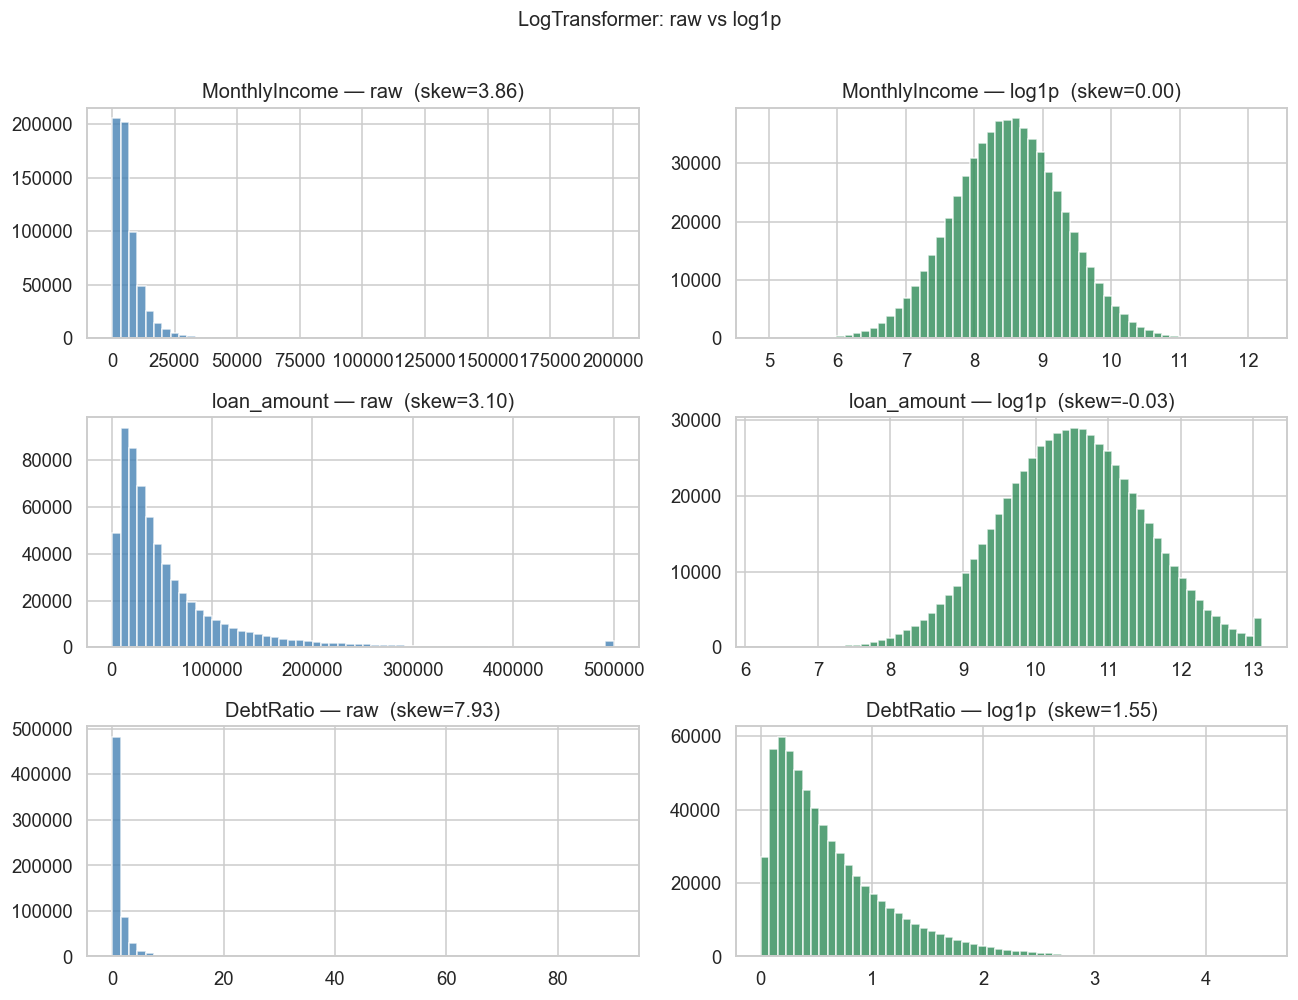

In [5]:
log_cols = LogTransformer.COLS_TO_LOG
log_t = LogTransformer()
X_logged = log_t.fit_transform(X_train)

fig, axes = plt.subplots(len(log_cols), 2, figsize=(12, len(log_cols) * 3))

for i, col in enumerate(log_cols):
    if col not in X_train.columns:
        continue
    raw_vals = X_train[col].dropna()
    log_vals = X_logged[col].dropna()

    axes[i, 0].hist(raw_vals, bins=60, color='steelblue', alpha=0.8)
    axes[i, 0].set_title(f'{col} — raw  (skew={raw_vals.skew():.2f})')

    axes[i, 1].hist(log_vals, bins=60, color='seagreen', alpha=0.8)
    axes[i, 1].set_title(f'{col} — log1p  (skew={log_vals.skew():.2f})')

plt.suptitle('LogTransformer: raw vs log1p', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 2. DelinquencyRatioTransformer

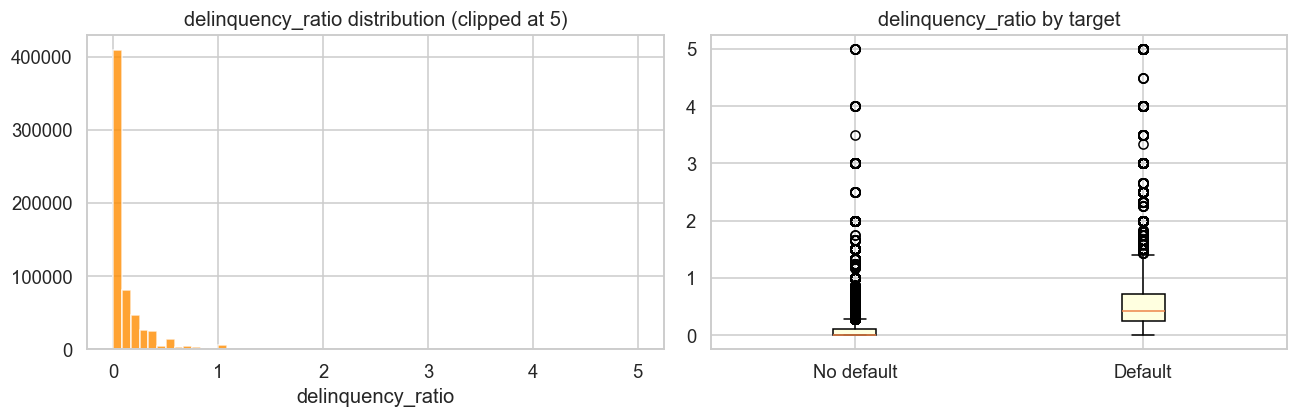

Pearson correlation with target: 0.4974


In [6]:
delinq_t = DelinquencyRatioTransformer()
X_delinq = delinq_t.fit_transform(X_logged)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(X_delinq['delinquency_ratio'].clip(upper=5), bins=60, color='darkorange', alpha=0.8)
axes[0].set_title('delinquency_ratio distribution (clipped at 5)')
axes[0].set_xlabel('delinquency_ratio')

axes[1].boxplot(
    [X_delinq.loc[y_train == 0, 'delinquency_ratio'].clip(upper=5),
     X_delinq.loc[y_train == 1, 'delinquency_ratio'].clip(upper=5)],
    labels=['No default', 'Default'], patch_artist=True,
    boxprops=dict(facecolor='lightyellow'),
)
axes[1].set_title('delinquency_ratio by target')

plt.tight_layout()
plt.show()

ratio_corr = X_delinq['delinquency_ratio'].corr(y_train)
print(f"Pearson correlation with target: {ratio_corr:.4f}")

## 3. Full preprocessor output

In [7]:
preprocessor = build_preprocessor()
X_pre = preprocessor.fit_transform(X_delinq)

print(f"Preprocessor output shape: {X_pre.shape}")
print(f"NaN count in output: {np.isnan(X_pre).sum()}")
feature_names = get_feature_names_out(preprocessor)
print(f"\nFeature names ({len(feature_names)}):")
for name in feature_names:
    print(f"  {name}")

Preprocessor output shape: (631361, 13)
NaN count in output: 0

Feature names (13):
  RevolvingUtilizationOfUnsecuredLines
  age
  NumberOfTime30-59DaysPastDueNotWorse
  DebtRatio
  MonthlyIncome
  NumberOfOpenCreditLinesAndLoans
  NumberOfTimes90DaysLate
  NumberRealEstateLoansOrLines
  NumberOfTime60-89DaysPastDueNotWorse
  NumberOfDependents
  loan_amount
  employment_years
  credit_score_band


## 4. Scaled numeric features — mean ≈ 0, std ≈ 1

In [8]:
X_pre_df = pd.DataFrame(X_pre, columns=feature_names)
stats_df = X_pre_df.describe().T[['mean', 'std', 'min', 'max']].round(4)
stats_df

,mean,std,min,max
RevolvingUtilizationOfUnsecuredLines,-0.0000,1.0000,-0.9556,3.4091
age,-0.0000,1.0000,-1.7074,1.7070
NumberOfTime30-59DaysPastDueNotWorse,0.0000,1.0000,-0.4619,10.2317
DebtRatio,-0.0000,1.0000,-1.1961,7.2204
MonthlyIncome,0.0000,1.0000,-4.5643,4.6820
NumberOfOpenCreditLinesAndLoans,-0.0000,1.0000,-1.7306,7.7179
NumberOfTimes90DaysLate,-0.0000,1.0000,-0.3734,11.9661
NumberRealEstateLoansOrLines,-0.0000,1.0000,-1.4146,1.4128
NumberOfTime60-89DaysPastDueNotWorse,0.0000,1.0000,-0.3157,16.7517
NumberOfDependents,-0.0000,1.0000,-1.5580,1.5430


## 5. Credit score band — ordinal encoding

In [9]:
band_mapping = dict(zip(
    ['Poor', 'Fair', 'Good', 'Very Good', 'Exceptional'],
    range(5)
))
print("Ordinal encoding:", band_mapping)

# Verify in preprocessed data
encoded_vals = X_pre_df['credit_score_band'].unique()
print(f"Unique encoded values: {sorted(encoded_vals)}")

Ordinal encoding: {'Poor': 0, 'Fair': 1, 'Good': 2, 'Very Good': 3, 'Exceptional': 4}
Unique encoded values: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]


## 6. Feature-target correlation after preprocessing

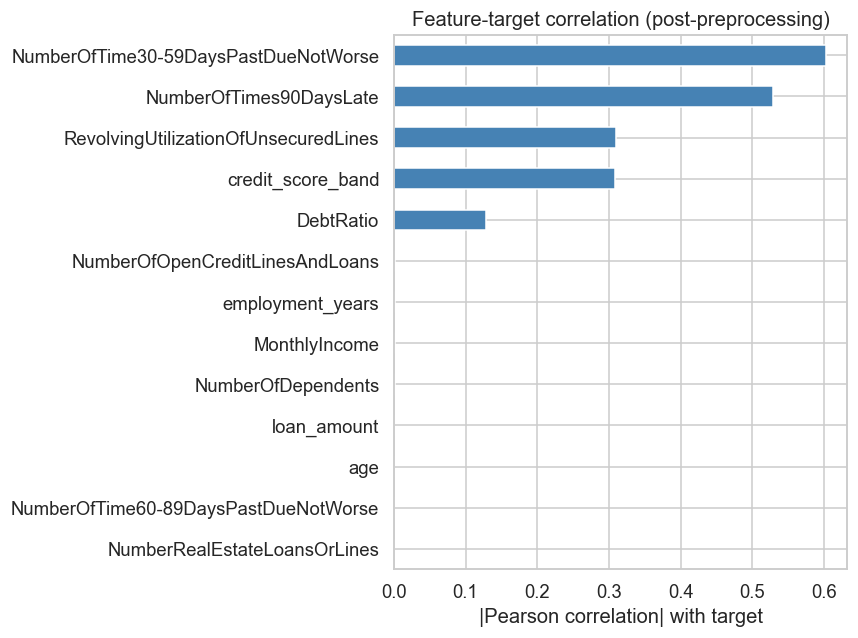

In [10]:
correlations = X_pre_df.corrwith(y_train.reset_index(drop=True)).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
correlations.plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('|Pearson correlation| with target')
ax.set_title('Feature-target correlation (post-preprocessing)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Pipeline step summary

In [11]:
from sklearn.linear_model import LogisticRegression

pipeline = build_full_pipeline(LogisticRegression(max_iter=100))
print("Pipeline steps:")
for name, step in pipeline.steps:
    print(f"  {name}: {type(step).__name__}")

Pipeline steps:
  log_transform: LogTransformer
  delinquency: DelinquencyRatioTransformer
  preprocessor: ColumnTransformer
  model: LogisticRegression
